In [2]:
#pip install yfinance

In [120]:
import yfinance as yf
import datetime
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

####
#### Preparing Stock list for data collection

In [17]:
# ---- Defining the list of stock to be used ---
stock_tickers = ["HDFCBANK.NS", "BANKBARODA.NS", "AXISBANK.NS", "PNB.NS", "SBIN.NS"]

In [8]:
# ---- Verifying ticker names with Bank Names ---
for ticker in tickers:
    stock = yf.Ticker(ticker)
    try:
        print(f"{ticker}: {stock.info['shortName']}")
    except:
        print(f"{ticker}: info not available")

HDFCBANK.NS: HDFC BANK LTD
BANKBARODA.NS: BANK OF BARODA
AXISBANK.NS: AXIS BANK LIMITED
PNB.NS: PUNJAB NATIONAL BANK
SBIN.NS: STATE BANK OF INDIA


In [10]:
#dir(ticker)

In [11]:
# ---- Defining NIFTY 50 Stock ticker ---
index_ticker = '^NSEI'  # NIFTY 50 Index

In [16]:
nifty = yf.Ticker(index_ticker)
print(nifty.info['shortName']) 

NIFTY 50


In [20]:
# ---- Defining the start and the end date for the analysis - 6 months from current date ---
end_date = datetime.datetime.today()
start_date = end_date - datetime.timedelta(days=180)  

In [29]:
# ---- Checking the column names present in downloaded data by pulling for only one stock ---
data = yf.download("HDFCBANK.NS", start="2024-12-01", end="2025-07-01")
print(data.columns)

/var/folders/gp/956lb2_920131z04zsw_fgyc0000gr/T/ipykernel_72623/937629679.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AXISBANK.NS", start="2024-12-01", end="2025-07-01")
[*********************100%***********************]  1 of 1 completed

MultiIndex([( 'Close', 'AXISBANK.NS'),
            (  'High', 'AXISBANK.NS'),
            (   'Low', 'AXISBANK.NS'),
            (  'Open', 'AXISBANK.NS'),
            ('Volume', 'AXISBANK.NS')],
           names=['Price', 'Ticker'])


In [139]:
# ---- importing data collected in csv ---
data.to_csv("bank_stocks_closing_prices.csv")

In [24]:
# ---- Verifying some sample data pulled in above step ---
data.head(5)

Price,Close,High,Low,Open,Volume
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
Date,,,,,
2024-12-02,1785.062378,1788.474910,1755.685602,1783.875484,7555438
2024-12-03,1806.427368,1817.406561,1796.338286,1802.866445,21705121
2024-12-04,1839.859497,1844.706202,1811.224562,1818.000000,22334542
2024-12-05,1845.448120,1859.493557,1815.230497,1839.760688,19841357
2024-12-06,1835.655762,1843.914878,1823.934730,1836.793272,8891578


####
#### Data Collection

In [31]:
# ---- Combine all tickers in single variable (Stocks + NIFTY 50) ---
all_tickers = stock_tickers + [index_ticker]

In [37]:
# ---- Downloading the data for all tickers for last 6 months ---
data = yf.download(all_tickers, start=start_date, end=end_date)

/var/folders/gp/956lb2_920131z04zsw_fgyc0000gr/T/ipykernel_72623/3750337166.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start=start_date, end=end_date)
[*********************100%***********************]  6 of 6 completed


In [40]:
# ---- Checking some sample records downloaded for all tickers ---
data.head(5)

Price             Close                                                    \
Ticker      AXISBANK.NS BANKBARODA.NS  HDFCBANK.NS     PNB.NS     SBIN.NS   
Date                                                                        
2025-01-13  1048.404053    210.437729  1613.104126  92.732895  715.140320   
2025-01-14  1050.752075    216.266830  1628.682739  95.638695  733.423218   
2025-01-15  1025.923218    214.623474  1625.171387  95.483200  738.863953   
2025-01-16  1037.113647    221.225937  1634.073486  97.397728  751.215881   
2025-01-17   990.203735    220.404251  1618.939941  97.310257  749.059204   

Price                            High                                        \
Ticker             ^NSEI  AXISBANK.NS BANKBARODA.NS  HDFCBANK.NS     PNB.NS   
Date                                                                          
2025-01-13  23085.949219  1062.092306    216.953178  1628.831137  95.726161   
2025-01-14  23176.050781  1060.094067    218.905877  1638.178254  96.387008   
2025-01-15  23213.199219  1052.000905    218.364542  1644.607471  97.125611   
2025-01-16  23311.800781  1045.556383    223.255967  1642.480995  99.030418   
2025-01-17  23203.199219  1010.836127    221.274262  1632.540323  97.864205   

Price       ...         Open                                           Volume  \
Ticker      ...  HDFCBANK.NS     PNB.NS     SBIN.NS         ^NSEI AXISBANK.NS   
Date        ...                                                                 
2025-01-13  ...  1622.154586  95.240242  726.904108  23195.400391     7180930   
2025-01-14  ...  1622.055693  92.762044  718.522407  23165.900391     6892897   
2025-01-15  ...  1638.474984  96.212079  738.324791  23250.449219    11418721   
2025-01-16  ...  1634.864709  96.698003  745.432055  23377.250000    10261727   
2025-01-17  ...  1625.616492  97.319977  751.215911  23277.099609    33831617   

Price                                                               
Ticker     BANKBARODA.NS HDFCBANK.NS    PNB.NS   SBIN.NS     ^NSEI  
Date                                                                
2025-01-13      14375458    10834533  32108507  10414733  316500.0  
2025-01-14      10793343    13330716  26803252  11960975  311200.0  
2025-01-15       8409931     7011446  22113146   7792299  228000.0  
2025-01-16      13044666    10606227  22309415  11816079  299400.0  
2025-01-17       6060015    11556038  16236187   5766573  272900.0  

[5 rows x 30 columns]

In [43]:
# ---- If the stock has column Adjusted Close Price, using that else using Close Price Column  ---
if isinstance(data.columns, pd.MultiIndex):
    if 'Adj Close' in data.columns.get_level_values(0):
        stock_close_df = data['Adj Close']
    else:
        stock_close_df = data['Close']
else:
    # Single ticker (unlikely in your case, but safe fallback)
    if 'Adj Close' in data.columns:
        stock_close_df = data[['Adj Close']]
        stock_close_df.columns = tickers  # rename column to ticker name
    else:
        stock_close_df = data[['Close']]
        stock_close_df.columns = tickers

In [44]:
# ---- Checking some sample data for all stock and Nifty close price ---
stock_close_df.head(10)

Ticker,AXISBANK.NS,BANKBARODA.NS,HDFCBANK.NS,PNB.NS,SBIN.NS,^NSEI
Date,,,,,,
2025-01-13,1048.404053,210.437729,1613.104126,92.732895,715.140320,23085.949219
2025-01-14,1050.752075,216.266830,1628.682739,95.638695,733.423218,23176.050781
2025-01-15,1025.923218,214.623474,1625.171387,95.483200,738.863953,23213.199219
2025-01-16,1037.113647,221.225937,1634.073486,97.397728,751.215881,23311.800781
2025-01-17,990.203735,220.404251,1618.939941,97.310257,749.059204,23203.199219
2025-01-20,987.206299,224.386993,1633.282104,98.155762,763.911011,23344.750000
2025-01-21,969.371582,221.960617,1624.528442,97.494904,744.108582,23024.650391
2025-01-22,958.480835,220.771591,1647.921143,95.434608,738.618835,23155.349609
2025-01-23,950.237915,221.525604,1646.783691,96.629974,731.217468,23205.349609


####
#### Computing Daily Returns

In [54]:
# ---- Computing Daily log returns ---
log_returns_df = np.log(stock_close_df / stock_close_df.shift(1))

log_returns_df

Ticker,AXISBANK.NS,BANKBARODA.NS,HDFCBANK.NS,PNB.NS,SBIN.NS,^NSEI
Date,,,,,,
2025-01-13,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-14,0.002237,0.027323,0.009611,0.030854,0.025244,0.003895
2025-01-15,-0.023913,-0.007628,-0.002158,-0.001627,0.007391,0.001602
2025-01-16,0.010849,0.030299,0.005463,0.019853,0.016579,0.004239
2025-01-17,-0.046286,-0.003721,-0.009304,-0.000898,-0.002875,-0.004670
...,...,...,...,...,...,...
2025-07-07,-0.002125,0.001287,-0.000956,0.014864,-0.006178,0.000012
2025-07-08,-0.008289,-0.005532,0.007020,-0.004454,0.007163,0.002401
2025-07-09,-0.000601,0.005698,0.004885,-0.009058,-0.002094,-0.001820


####
#### Computing Excess Return per stock

In [53]:
# ---- Pulling Nifty log returns separately ---
nifty_log_return = log_returns_df['^NSEI']

nifty_log_return

Date
2025-01-13         NaN
2025-01-14    0.003895
2025-01-15    0.001602
2025-01-16    0.004239
2025-01-17   -0.004670
                ...   
2025-07-07    0.000012
2025-07-08    0.002401
2025-07-09   -0.001820
2025-07-10   -0.004755
2025-07-11   -0.008134
Name: ^NSEI, Length: 124, dtype: float64

In [101]:
# ---- Calculating daily excess returns per stock ---
excess_returns = log_returns_df[stock_tickers].subtract(nifty_log_return, axis=0)
excess_returns

Ticker,HDFCBANK.NS,BANKBARODA.NS,AXISBANK.NS,PNB.NS,SBIN.NS
Date,,,,,
2025-01-13,NaN,NaN,NaN,NaN,NaN
2025-01-14,0.005716,0.023428,-0.001658,0.026959,0.021349
2025-01-15,-0.003760,-0.009229,-0.025515,-0.003229,0.005789
2025-01-16,0.001224,0.026061,0.006610,0.015614,0.012341
2025-01-17,-0.004635,0.000948,-0.041617,0.003771,0.001794
...,...,...,...,...,...
2025-07-07,-0.000967,0.001275,-0.002137,0.014852,-0.006190
2025-07-08,0.004619,-0.007933,-0.010690,-0.006855,0.004762
2025-07-09,0.006704,0.007518,0.001219,-0.007238,-0.000274


####
#### Anomaly Detection

In [132]:
#dropping NaNs from the data

excess_returns = excess_returns.dropna().copy()

In [133]:
# Fit Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)

In [134]:
model.fit(excess_returns)

IsolationForest(contamination=0.05, random_state=42)

In [135]:
# ---- Calculating scores ---
scores = model.decision_function(excess_returns)

In [136]:
# ---- Identifying Anomalies ---
Anomaly = model.predict(excess_returns)  

In [116]:
# ---- Storing scores in excess_returns dataframe ---
excess_returns.loc[:, 'scores'] = scores

In [117]:
# ---- Storing Anomalies in excess_returns dataframe ---
excess_returns.loc[:, 'Anomaly'] = Anomaly

In [118]:
excess_returns

Ticker,HDFCBANK.NS,BANKBARODA.NS,AXISBANK.NS,PNB.NS,SBIN.NS,scores,Anomaly
Date,,,,,,,
2025-01-14,0.005716,0.023428,-0.001658,0.026959,0.021349,0.105005,1
2025-01-15,-0.003760,-0.009229,-0.025515,-0.003229,0.005789,0.136306,1
2025-01-16,0.001224,0.026061,0.006610,0.015614,0.012341,0.139000,1
2025-01-17,-0.004635,0.000948,-0.041617,0.003771,0.001794,0.051310,1
2025-01-20,0.002738,0.011827,-0.009114,0.002569,0.013551,0.163537,1
...,...,...,...,...,...,...,...
2025-07-07,-0.000967,0.001275,-0.002137,0.014852,-0.006190,0.184414,1
2025-07-08,0.004619,-0.007933,-0.010690,-0.006855,0.004762,0.190009,1
2025-07-09,0.006704,0.007518,0.001219,-0.007238,-0.000274,0.194006,1


####
#### List of dates where Anomalies are detected

In [119]:
# ---- Fetching Anomalies i.e. anomaly = -1 ---
excess_returns[excess_returns.Anomaly == -1]

Ticker,HDFCBANK.NS,BANKBARODA.NS,AXISBANK.NS,PNB.NS,SBIN.NS,scores,Anomaly
Date,,,,,,,
2025-01-28,0.019010,0.004101,0.031367,0.038141,-0.001333,-0.012211,-1
2025-02-28,0.037289,-0.011712,0.017689,-0.032152,-0.002864,-0.026738,-1
2025-03-19,0.016306,0.035036,0.013956,0.036578,0.026697,-0.047736,-1
2025-04-23,-0.026126,-0.010558,-0.014838,-0.010254,-0.017611,-0.026073,-1
2025-05-06,0.000703,-0.103391,-0.006769,-0.047530,-0.016992,-0.103680,-1
2025-06-30,-0.001952,0.035125,-0.016647,0.043095,0.023113,-0.003644,-1


####
#### Time Series Visualisation

In [122]:
anomalous_dates = excess_returns[excess_returns['Anomaly'] == -1].index

In [138]:
#print(plt.style.available)

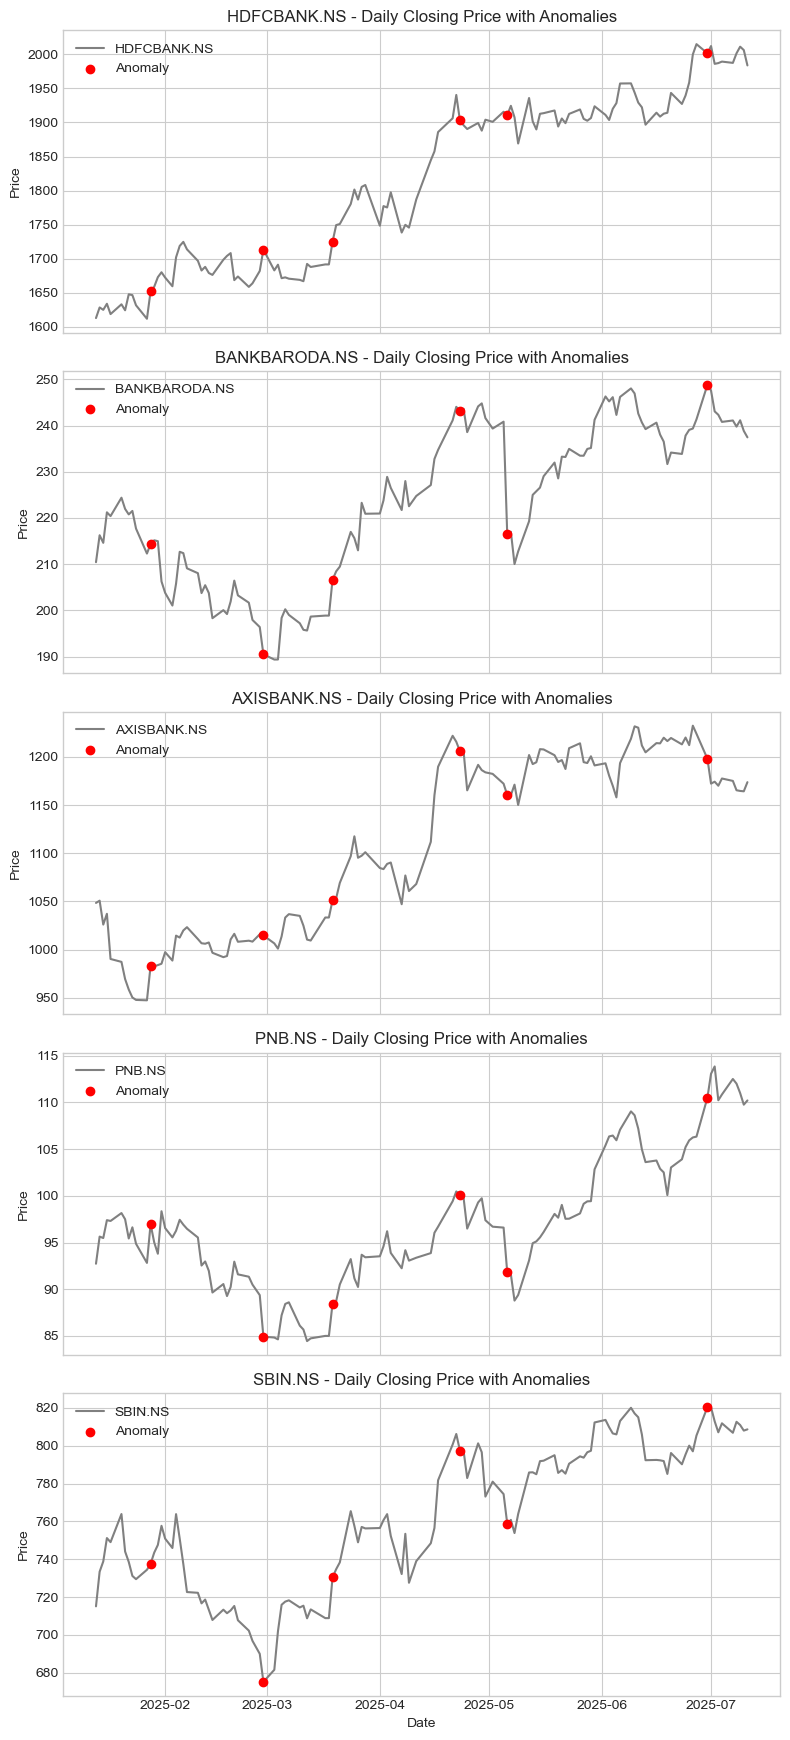

In [131]:
# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(len(tickers), 1, figsize=(8, 3.5 * len(tickers)), sharex=True)

for i, ticker in enumerate(tickers):
    ax = axs[i]
    
    # Plot the time series of closing price
    ax.plot(stock_close_df.index, stock_close_df[ticker], label=f'{ticker}', color='gray')
    
    # Mark anomalies
    ax.scatter(anomalous_dates, stock_close_df.loc[anomalous_dates, ticker], 
               color='red', marker='o', label='Anomaly', zorder=5)
    
    # Title and labels
    ax.set_title(f'{ticker} - Daily Closing Price with Anomalies')
    ax.set_ylabel("Price")
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Shared x-label
plt.xlabel("Date")
plt.tight_layout()
plt.show()

####
#### Anomalies Explanation
####
##### Stock Anomaly in March 2025 
- Reserve Bank of India (RBI) conducted Open Market Operations (OMO) and it attracted bids more than double the amount notified.
- OMO can positively influence bank stock benefits, with OMO RBI injects liquidity into banking system which leads to lower interest rates and increased lending capacity, thereby boosting bank profitability and stock prices.
- Link: https://economictimes.indiatimes.com/markets/forex/forex-news/rbi-to-hold-another-omo-on-march-25-to-infuse-rs-50000-crore/articleshow/119167915.cms?from=mdr
#####
##### Stock Anomaly in Jan 2025
- FPI (Foreign Portfolio Investors) reversed course, withdrew a lot of fund, biggest monthly outflow in over two decades.
- Indian Markets rebounded sharply.
- Because of this behaviour by FPI, there was a disproportionate return on 28 Jan 2025
- Link: https://economictimes.indiatimes.com/markets/stocks/news/fpi-outflows-at-rs-1-lakh-crore-in-2025-so-far-rs-555-crore-pulled-out-in-july-alone/articleshow/122405786.cms?from=mdr